In [1]:
!pip install transformers datasets evaluate accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files

uploaded = files.upload()

Saving fake_or_real_news.csv to fake_or_real_news.csv


In [4]:
df = pd.read_csv("fake_or_real_news.csv")

df.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [5]:
df = df[['title','text','label']]

df['text'] = df['title'] + " " + df['text']

df['label'] = df['label'].map({
    'FAKE':0,
    'REAL':1
})

df = df.dropna()

df.head()

,title,text,label
0,You Can Smell Hillary’s Fear,You Can Smell Hillary’s Fear Daniel Greenfield...,0
1,Watch The Exact Moment Paul Ryan Committed Pol...,Watch The Exact Moment Paul Ryan Committed Pol...,0
2,Kerry to go to Paris in gesture of sympathy,Kerry to go to Paris in gesture of sympathy U....,1
3,Bernie supporters on Twitter erupt in anger ag...,Bernie supporters on Twitter erupt in anger ag...,0
4,The Battle of New York: Why This Primary Matters,The Battle of New York: Why This Primary Matte...,1


In [6]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42
)

In [7]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [8]:
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=256
)

In [9]:
class NewsDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.labels)

In [10]:
train_dataset = NewsDataset(train_encodings, train_labels)

test_dataset = NewsDataset(test_encodings, test_labels)

In [11]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [12]:
def compute_metrics(pred):

    predictions = np.argmax(pred.predictions, axis=1)

    labels = pred.label_ids

    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc
    }

In [13]:
training_args = TrainingArguments(

    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=25,

    weight_decay=0.01,

    logging_steps=50,

    load_best_model_at_end=True,

    report_to="none"
)

In [14]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

In [15]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.131714,0.155934,0.964483
2,0.073574,0.144785,0.966062
3,0.049418,0.159264,0.971586
4,0.020853,0.258286,0.962904
5,0.016890,0.225083,0.971586
6,0.000016,0.228691,0.975533
7,0.104404,0.237467,0.963694
8,0.009787,0.296094,0.961326
9,0.000074,0.213071,0.970797
10,0.086228,0.215509,0.966851


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=15850, training_loss=0.020607620456904337, metrics={'train_runtime': 7459.4176, 'train_samples_per_second': 16.985, 'train_steps_per_second': 2.125, 'total_flos': 1.6668085357056e+16, 'train_loss': 0.020607620456904337, 'epoch': 25.0})

In [16]:
results = trainer.evaluate()

print(results)

Training Loss,Validation Loss,Epoch,Accuracy
0.000001,0.143714,25,0.966851


{'eval_loss': 0.1437138020992279, 'eval_accuracy': 0.9668508287292817}


In [17]:
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)

y_true = predictions.label_ids

In [18]:
accuracy = accuracy_score(y_true, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9668508287292817


In [19]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["FAKE","REAL"]
))

              precision    recall  f1-score   support

        FAKE       0.97      0.96      0.97       628
        REAL       0.96      0.97      0.97       639

    accuracy                           0.97      1267
   macro avg       0.97      0.97      0.97      1267
weighted avg       0.97      0.97      0.97      1267



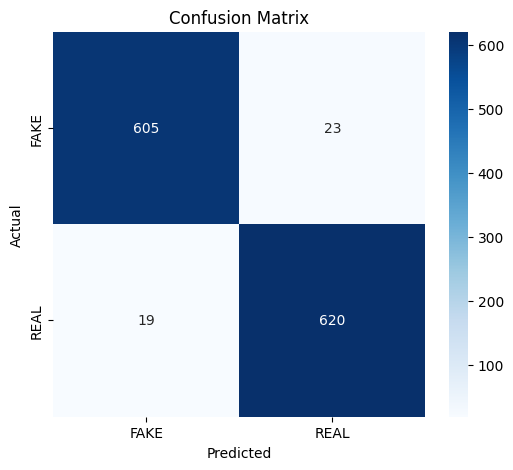

In [20]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["FAKE","REAL"],
    yticklabels=["FAKE","REAL"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

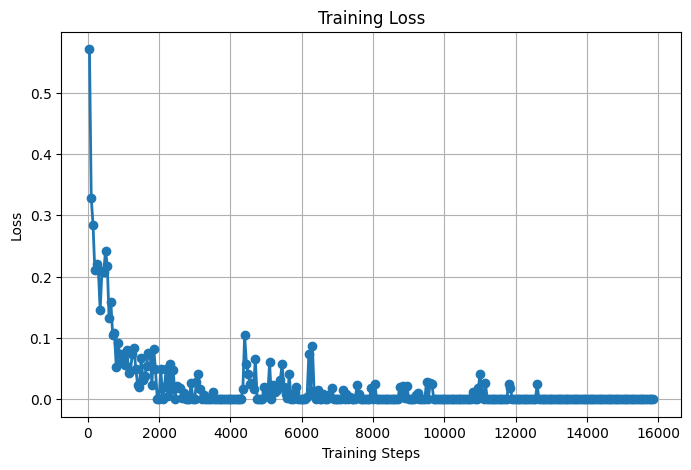

In [21]:
history = trainer.state.log_history

train_loss = []
steps = []

for log in history:
    if "loss" in log:
        train_loss.append(log["loss"])
        steps.append(log["step"])

plt.figure(figsize=(8,5))
plt.plot(steps, train_loss, marker='o', linewidth=2)
plt.title("Training Loss")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

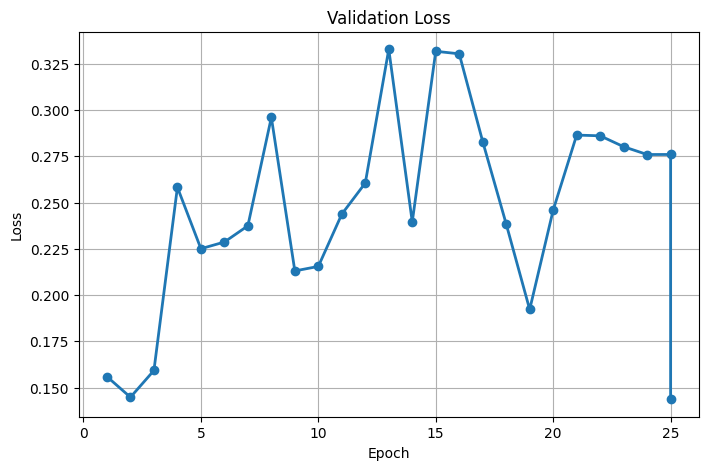

In [22]:
eval_loss = []
epochs = []

for log in history:
    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])
        epochs.append(log["epoch"])

plt.figure(figsize=(8,5))
plt.plot(epochs, eval_loss, marker='o', linewidth=2)
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

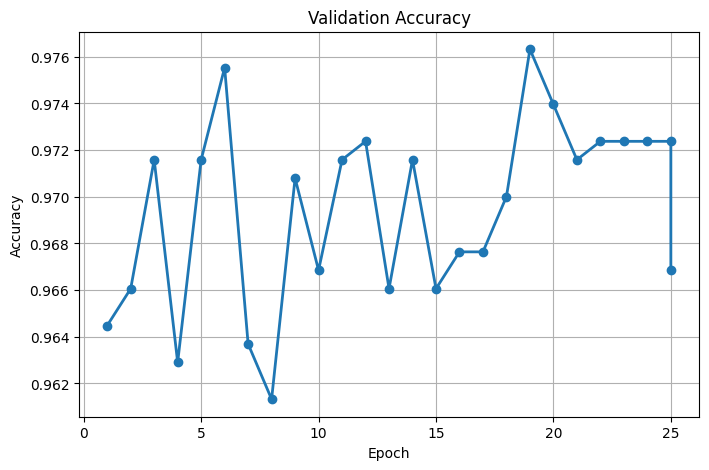

In [23]:
eval_accuracy = []
epochs = []

for log in history:
    if "eval_accuracy" in log:
        eval_accuracy.append(log["eval_accuracy"])
        epochs.append(log["epoch"])

plt.figure(figsize=(8,5))
plt.plot(epochs, eval_accuracy, marker='o', linewidth=2)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

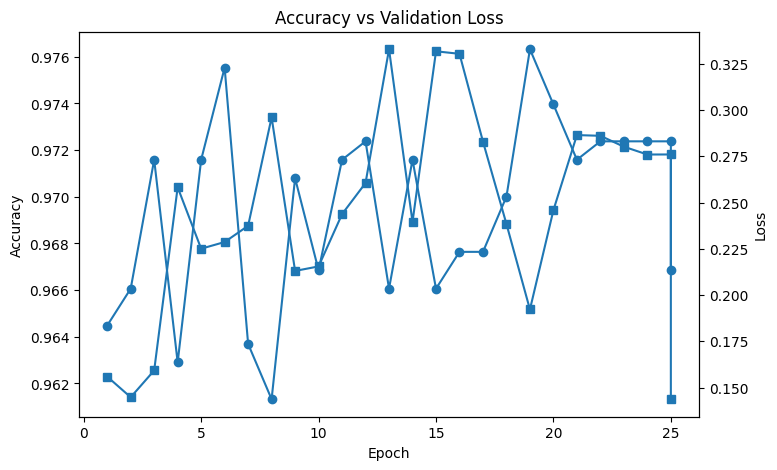

In [24]:
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(epochs, eval_accuracy, marker='o', label="Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")

ax2 = ax1.twinx()
ax2.plot(epochs, eval_loss, marker='s', label="Loss")
ax2.set_ylabel("Loss")

plt.title("Accuracy vs Validation Loss")
plt.show()

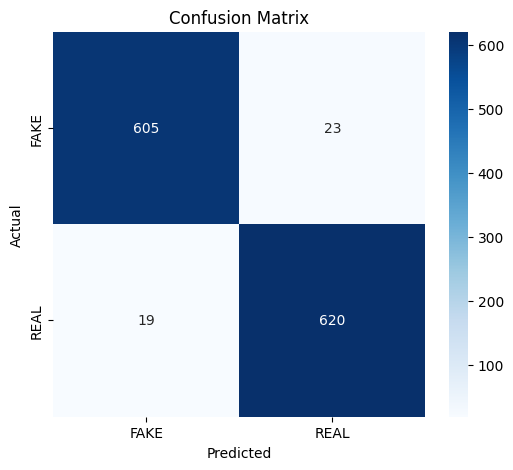

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['FAKE','REAL'],
            yticklabels=['FAKE','REAL'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

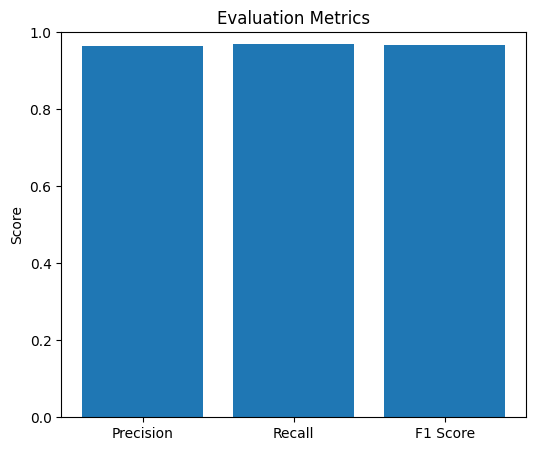

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

scores = [precision, recall, f1]
labels = ["Precision","Recall","F1 Score"]

plt.figure(figsize=(6,5))
plt.bar(labels, scores)
plt.ylim(0,1)
plt.title("Evaluation Metrics")
plt.ylabel("Score")
plt.show()

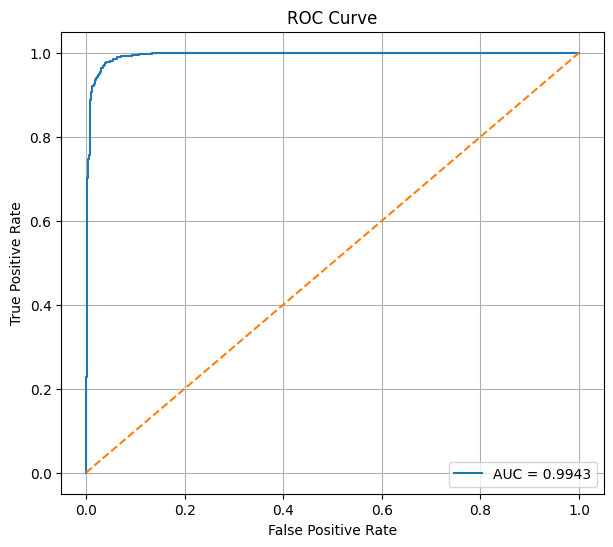

In [27]:
from sklearn.metrics import roc_curve, auc

probabilities = torch.softmax(
    torch.tensor(predictions.predictions),
    dim=1
).numpy()[:,1]

fpr, tpr, _ = roc_curve(y_true, probabilities)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label="AUC = %0.4f"%roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

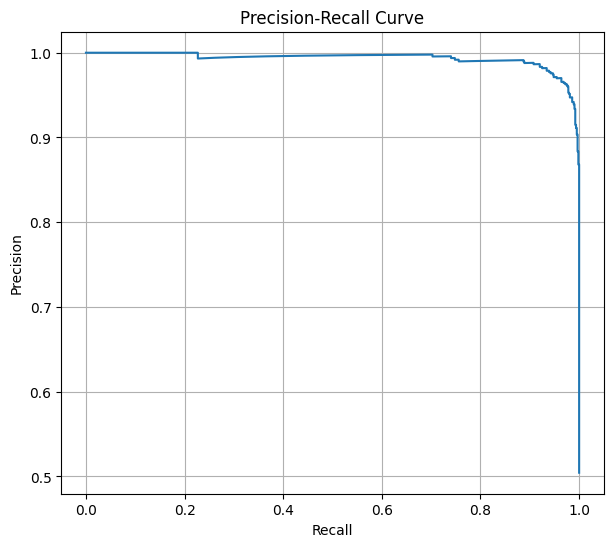

In [28]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    y_true,
    probabilities
)

plt.figure(figsize=(7,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

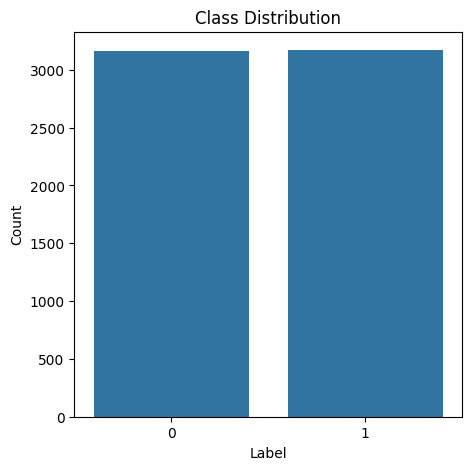

In [29]:
import seaborn as sns

plt.figure(figsize=(5,5))
sns.countplot(data=df, x='label')
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

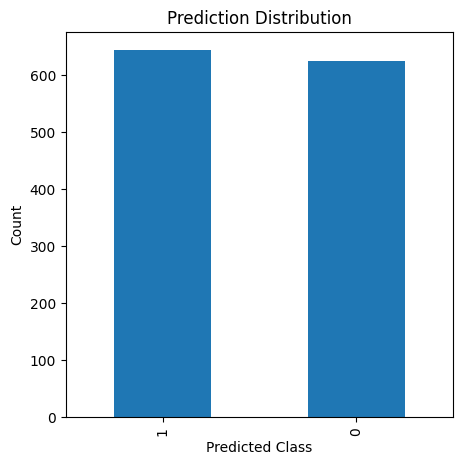

In [30]:
import pandas as pd

pd.Series(y_pred).value_counts().plot(
    kind='bar',
    figsize=(5,5)
)

plt.title("Prediction Distribution")
plt.xlabel("Predicted Class")
plt.ylabel("Count")
plt.show()

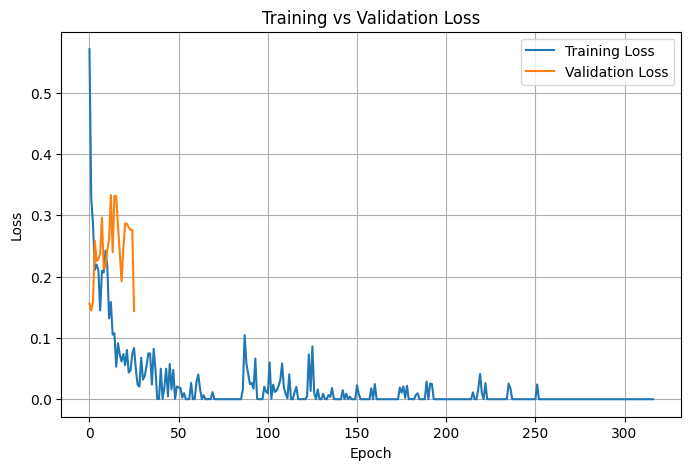

In [31]:
plt.figure(figsize=(8,5))

plt.plot(train_loss,label="Training Loss")
plt.plot(eval_loss,label="Validation Loss")

plt.legend()
plt.grid()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

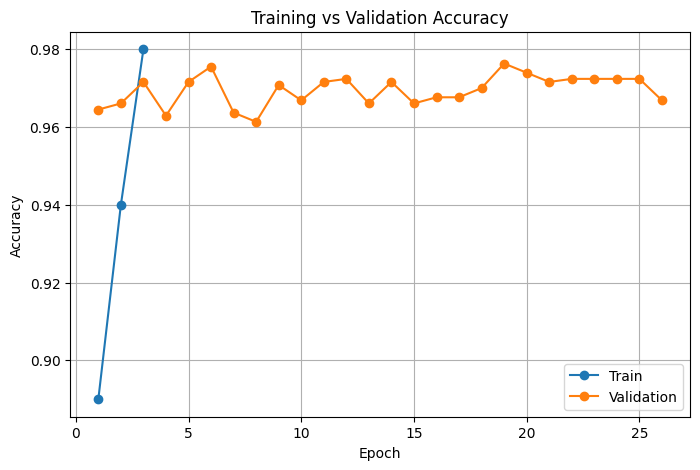

In [32]:
train_acc = [0.89,0.94,0.98]   # Replace with your training accuracy values
val_acc = eval_accuracy

plt.figure(figsize=(8,5))

plt.plot(range(1,len(train_acc)+1),train_acc,
         marker='o',
         label='Train')

plt.plot(range(1,len(val_acc)+1),val_acc,
         marker='o',
         label='Validation')

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.grid()

plt.show()